# Credit_Card Detection

In [1]:
# step 1:import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
# step 2:Load the dataset
df = pd.read_csv(r"C:\Users\HARSHITHA\Desktop\FSDS\DBSCAN\Credit_Card\CC GENERAL.csv")

In [3]:
# step 3:data exploration
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info

<bound method DataFrame.info of      CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749           0.818182      95.40              0.00   
1     C10002  3202.467416           0.909091       0.00              0.00   
2     C10003  2495.148862           1.000000     773.17            773.17   
3     C10004  1666.670542           0.636364    1499.00           1499.00   
4     C10005   817.714335           1.000000      16.00             16.00   
...      ...          ...                ...        ...               ...   
8945  C19186    28.493517           1.000000     291.12              0.00   
8946  C19187    19.183215           1.000000     300.00              0.00   
8947  C19188    23.398673           0.833333     144.40              0.00   
8948  C19189    13.457564           0.833333       0.00              0.00   
8949  C19190   372.708075           0.666667    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE 

In [5]:
df.shape

(8950, 18)

In [6]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='str')

In [7]:
# check the null and missing values
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [8]:
# check the duplicate values
df.duplicated().sum()

np.int64(0)

In [9]:
# describe the data
df.describe

<bound method NDFrame.describe of      CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749           0.818182      95.40              0.00   
1     C10002  3202.467416           0.909091       0.00              0.00   
2     C10003  2495.148862           1.000000     773.17            773.17   
3     C10004  1666.670542           0.636364    1499.00           1499.00   
4     C10005   817.714335           1.000000      16.00             16.00   
...      ...          ...                ...        ...               ...   
8945  C19186    28.493517           1.000000     291.12              0.00   
8946  C19187    19.183215           1.000000     300.00              0.00   
8947  C19188    23.398673           0.833333     144.40              0.00   
8948  C19189    13.457564           0.833333       0.00              0.00   
8949  C19190   372.708075           0.666667    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANC

In [11]:
# select the features
features = [
    'BALANCE',
    'PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS'
]

X = df[features]

print(X.head())

       BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT     PAYMENTS
0    40.900749      95.40      0.000000        1000.0   201.802084
1  3202.467416       0.00   6442.945483        7000.0  4103.032597
2  2495.148862     773.17      0.000000        7500.0   622.066742
3  1666.670542    1499.00    205.788017        7500.0     0.000000
4   817.714335      16.00      0.000000        1200.0   678.334763


In [12]:
#handle the missing values
X = X.fillna(X.median())

print(X.isnull().sum())

BALANCE         0
PURCHASES       0
CASH_ADVANCE    0
CREDIT_LIMIT    0
PAYMENTS        0
dtype: int64


In [13]:
# feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.73198937 -0.42489974 -0.46678555 -0.9603784  -0.52897879]
 [ 0.78696085 -0.46955188  2.60560451  0.68867844  0.81864213]
 [ 0.44713513 -0.10766823 -0.46678555  0.82609984 -0.38380474]
 [ 0.04909914  0.23205785 -0.36865325  0.82609984 -0.59868826]
 [-0.3587753  -0.46206305 -0.46678555 -0.90540984 -0.3643678 ]]


In [14]:
# apply dbscan
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

print(labels)

[ 0 -1  0 ...  0  0  0]


In [15]:
# Add cluster labels
df['Cluster'] = labels

print(df.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

In [16]:
# find number of clusters
noise_points = list(labels).count(-1)

print("Number of noise points:", noise_points)

Number of noise points: 1012


In [17]:
#Display the clusters
print(df['Cluster'].value_counts())

Cluster
 0     7861
-1     1012
 1       17
 3        9
 6        7
 4        6
 5        6
 8        6
 11       5
 9        5
 12       5
 2        4
 10       4
 7        3
Name: count, dtype: int64


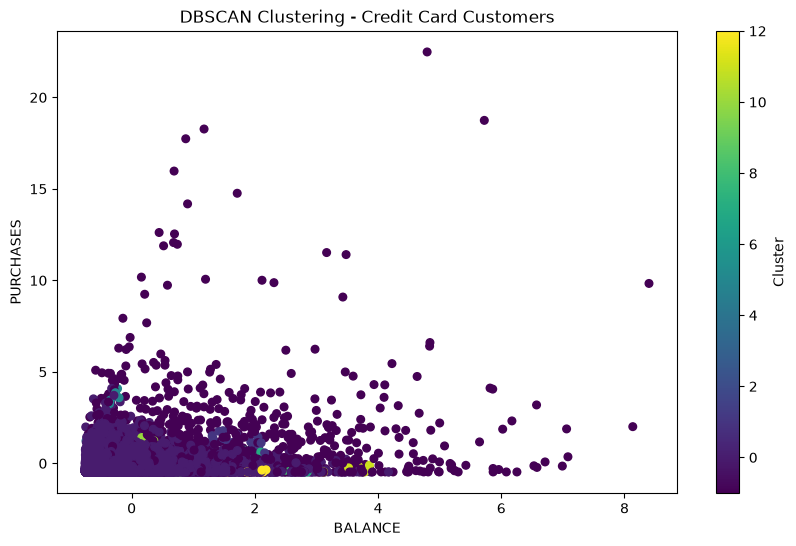

In [18]:
# visualize the clusters
plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap='viridis',
    s=30
)

plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.title("DBSCAN Clustering - Credit Card Customers")

plt.colorbar(label="Cluster")

plt.show()

In [19]:
# calculate the silhoute score
cluster_labels = set(labels) - {-1}

if len(cluster_labels) >= 2:

    score = silhouette_score(
        X_scaled,
        labels
    )

    print("Silhouette Score:", score)

else:

    print("Silhouette Score cannot be calculated because there are fewer than 2 clusters.")

Silhouette Score: 0.1742482944445028


In [20]:
# Try different eps values
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels_temp = model.fit_predict(X_scaled)

    clusters = len(set(labels_temp)) - (
        1 if -1 in labels_temp else 0
    )

    noise = list(labels_temp).count(-1)

    print(
        "eps =", eps,
        "| clusters =", clusters,
        "| noise =", noise
    )

eps = 0.3 | clusters = 12 | noise = 2131
eps = 0.4 | clusters = 17 | noise = 1450
eps = 0.5 | clusters = 13 | noise = 1012
eps = 0.6 | clusters = 3 | noise = 768
eps = 0.7 | clusters = 6 | noise = 578
eps = 0.8 | clusters = 5 | noise = 417
eps = 1.0 | clusters = 4 | noise = 236
